#### Bayesian Inference for Normal Mean with Known Variance and Normal Prior

Let $X1,...,Xn \sim N(\mu,\sigma)$

- Simulate a dataset (mu = 5) of n = 500 observations
- Take $f(\mu) = 1$ and compute the posterior density - plot it
- Simulate 5000 draws from the posterior. Plot it and compare with the above posterior density
- Let $\theta = e^{\mu}$. Compute the posterior density for $\theta$ analytically and by simulation
- Find a 95% posterior interval for $\theta$ and 95% confidence interval for $\theta$

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

n, mu, sigma = 500, 5, 1
X = norm.rvs(loc=mu, scale=sigma, size=n)

Take $f(\mu) = 1$ and compute the posterior density, plot it.

The posterior is proportional to likelihood times the prior
$f(\mu|X^n) \propto L_n(\mu)f(\mu) = L_n(\mu)$
The likelihood is the product of pdfs for each data point $L_n(\mu) = \prod_{i=1}^n f(X_i, \mu)$

We plot this with brute force or use the analytic approach that likelihood is proportional to a normal random variable in $\mu$ with $\hat{\mu} = \bar{X}$ and standard error $\sigma/\sqrt{n}$.
$L_n(\mu) \propto N(\bar{X}, \sigma^2/n)$

In [ ]:
''' posterior proportional to likelihood times prior f(mu) '''
mu_hat = X.mean()
mu_values = np.linspace(4, 6, 100)

In [ ]:
''' Brute force
compute the product for each sample - computing pdfs, taking logs, adding and exponentiating
'''
likelihood = np.vectorize(lambda mu: np.exp(np.log(norm.pdf(X, loc=mu, scale=sigma))))
#likelihood_values = likelihood(mu_values)

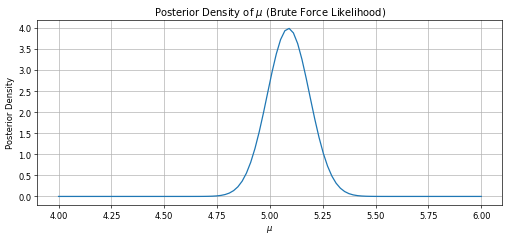

In [ ]:
''' Brute force
compute the product for each sample - computing pdfs, taking logs, adding and exponentiating
'''

likelihood_values = []
for m_val in mu_values:
    # Calculate the log-PDF for each data point X_i, given mu_val and the true sigma.
    # `sigma` is the correct scale for individual observations.
    log_pdfs = norm.logpdf(X, loc=m_val, scale=sigma)

    # Sum the log-PDFs to get the total log-likelihood for this mu_val.
    # This is numerically more stable than multiplying raw PDFs.
    total_log_likelihood = np.sum(log_pdfs)

    # Exponentiate to get the likelihood.
    likelihood_values.append(np.exp(total_log_likelihood))

Li = np.array(likelihood_values)

# Normalize the likelihoods to represent a density.
# Use np.trapezoid for numerical integration to normalize the continuous density over the interval.
if np.sum(Li) > 0 and not np.isnan(np.sum(Li)):
    normalized_Li = Li / np.trapezoid(Li, mu_values)

    fig = plt.subplots(1, figsize=(10, 4), dpi=60)
    plt.plot(mu_values, normalized_Li)
    plt.xlabel(r'$\mu$') ; plt.ylabel('Posterior Density')
    plt.title('Posterior Density of ' + r'$\mu$' + ' (Brute Force Likelihood)')
    plt.grid(True) ; plt.show()
else:
    print("Warning: Likelihood sum is zero or NaN, cannot plot a normalized density.")

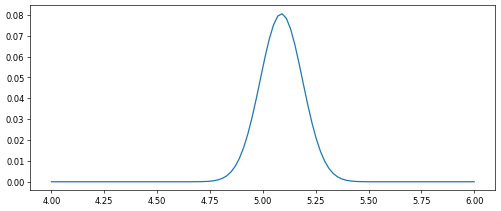

In [ ]:
''' Analytical approach '''
Li_a = norm.pdf(mu_values, loc=mu_hat, scale=sigma/np.sqrt(n))

fig = plt.subplots(1, figsize=(10, 4), dpi=60)
plt.plot(mu_values, Li_a/Li_a.sum())

Simulate 1000 draws from the posterior. Plot it and compare with the above posterior density

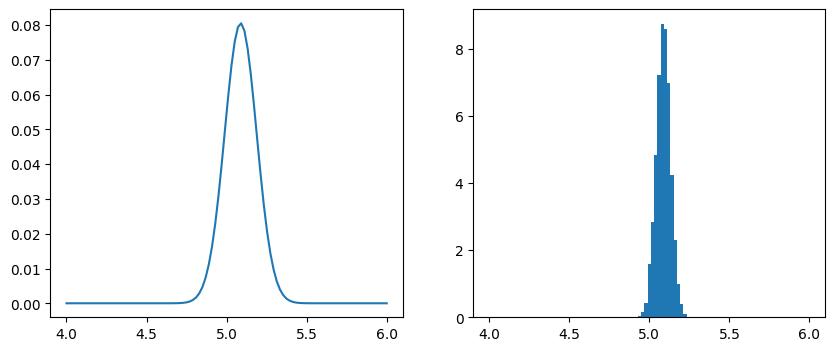

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(mu_values, Li_a/Li_a.sum() )

posterior_samples = norm.rvs(loc=mu_hat, scale=sigma/np.sqrt(n), size=5000)
ax2.hist(posterior_samples, bins=mu_values, density=True) ; plt.show()

Let theta = e^mu. Compute the posterior density for theta analytically and by simulation.

Let $\theta = e^{\mu}$.
For $Y = e^X$, $F_Y(z) = P_{\theta}(e^X \le z) = P_{\mu}(X \le \log(z)) = P_{\mu}\left(\frac{X - \mu}{\sigma} \le \frac{\log(z/e) - \mu}{\sigma}\right) = P(Z \le \log(z) - \mu) = \Phi(\log(z) - \mu)$
$\Phi$ - the CDF of standard normal distribution

The pdf of $f_Y(z) = F'_Y(z) = \frac{d\Phi(\log(z) - \mu)}{dz} = \frac{\phi(\log(z) - \mu)}{z}$ where
$\phi$ is the derivative of $\Phi$, and the pdf of the standard normal distribution.

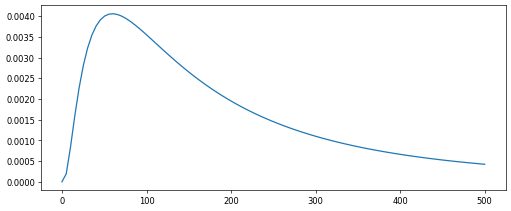

In [ ]:
def posterior_density(z):
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(z >0, norm.pdf(np.log(z) -mu_hat)/z, 0)
z_values = np.linspace(0, 500, 100)
f_values = posterior_density(z_values)

fig = plt.subplots(1, figsize=(10, 4), dpi=60)
plt.plot(z_values, f_values)

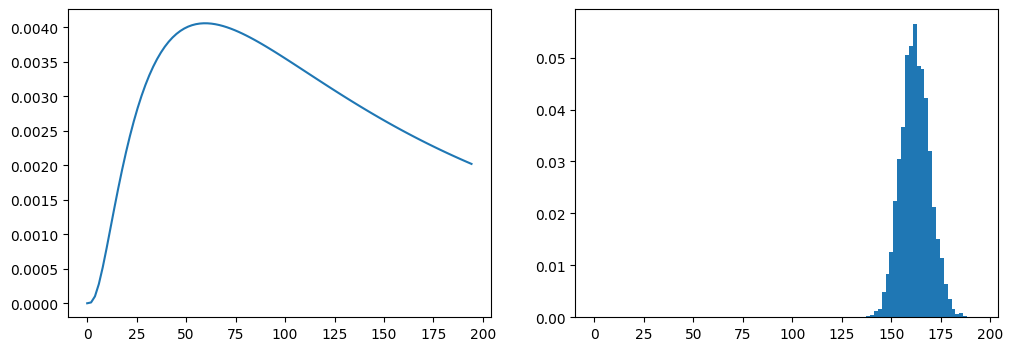

In [ ]:
''' Simulation: sample for the estimated parametric distribution '''
Y = np.exp(norm.rvs(loc=mu_hat, scale=sigma/np.sqrt(n), size=5000))
z_values = np.linspace(0, max(Y), 100)
f_values = posterior_density(z_values)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(z_values, f_values)
ax2.hist(Y, bins=z_values, density=True) ; plt.show()

95% posterior interval for theta and 955 confidence interval for theta


Since $\theta = e^\mu$ and $g(\mu) = e^\mu$ is a monotonically increasing function, the quantiles of $\theta$ can be found by taking the exponential of the quantiles of $\mu$. Specifically, if $P(\mu \le \mu_p) = p$, then $P(e^\mu \le e^{\mu_p}) = p$. This means that the $p$-th quantile of $\theta$ is $e^{\mu_p}$.

Analytically, the posterior distribution for $\mu$ is approximately $N(\bar{X}, \sigma^2/n)$, where $\bar{X} = \hat{\mu}$ is the maximum likelihood estimate for $\mu$. Therefore, the quantiles for $\mu$ can be obtained from this Normal distribution. For instance, the lower and upper bounds of a 95% posterior interval for $\mu$ are $\hat{\mu} \pm z_{0.975} \frac{\sigma}{\sqrt{n}}$.

More generally, for a monotonically increasing function $g$, if $Y = g(X)$, then the cumulative distribution function (CDF) of $Y$ is given by $F_Y(y) = P(Y \le y) = P(g(X) \le y) = P(X \le g^{-1}(y)) = F_X(g^{-1}(y))$. Consequently, the quantile function (inverse CDF) of $Y$ relates to that of $X$ by $Q_Y(p) = g(Q_X(p))$. This elegant property allows us to directly transform the posterior quantiles of $\mu$ to obtain the posterior quantiles of $\theta$.

In [ ]:
z_025 = norm.ppf(0.025)
z_975 = norm.ppf(0.975)

# Correct calculation: mu_hat + Z * (sigma / sqrt(n))
posterior_std_dev_mu = sigma / np.sqrt(n)
posterior_interval_analytic = (
    np.exp(mu_hat + z_025 * posterior_std_dev_mu),
    np.exp(mu_hat + z_975 * posterior_std_dev_mu)
)

print('posterior interval analytic %.2f, %.2f' % posterior_interval_analytic)
print('posterior interval simulation %.3f, %.3f' % (np.quantile(Y, 0.025), np.quantile(Y, 0.975)) )

posterior interval analytic 133.18, 197.09
posterior interval simulation 133.714, 197.663


#### Bayesian Inference for Uniform likelihood and prior

Given $X_1, \dots, X_n \sim \text{Uniform}(0, \theta)$ with prior density $f(\theta) \propto 1/\theta$.

**Likelihood Function:** The probability density function (PDF) for a single observation $X_i$ from a Uniform(0, $\theta$) distribution is:
$f(x_i | \theta) = \frac{1}{\theta}$ for $0 < x_i < \theta$, and $0$ otherwise.

For $n$ independent and identically distributed observations $X = (X_1, \dots, X_n)$, the likelihood function is the product of their PDFs:
$L(\theta | X) = \prod_{i=1}^n f(x_i | \theta) = \left(\frac{1}{\theta}\right)^n$ for $0 < x_i < \theta$ for all $i$.

This condition $0 < x_i < \theta$ for all $i$ implies that $\theta$ must be greater than the maximum observed value, $X_{\text{max}} = \max(X_1, \dots, X_n)$. And all $x_i$ must be greater than 0. So, we can write the likelihood as:
$L(\theta | X) = \frac{1}{\theta^n} \mathbb{I}(\theta > X_{\text{max}})$ where $\mathbb{I}(\cdot)$ is the indicator function.

**Prior Density:**
The given prior density is $f(\theta) \propto \frac{1}{\theta}$ for $\theta > 0$. This is an improper prior.

**Posterior Density (unnormalized):**
The posterior density is proportional to the likelihood times the prior:
$f(\theta | X) \propto L(\theta | X) f(\theta)$
$f(\theta | X) \propto \frac{1}{\theta^n} \cdot \frac{1}{\theta} = \frac{1}{\theta^{n+1}}$
This is valid for $\theta > X_{\text{max}}$.

**Normalization Constant:**
To find the normalized posterior density, we integrate the unnormalized posterior over its support $(\text{X}_{\text{max}}, \infty)$:
$C = \int_{X_{\text{max}}}^{\infty} \frac{1}{\theta^{n+1}} d\theta = \left[ \frac{\theta^{-n}}{-n} \right]_{X_{\text{max}}}^{\infty} = \left[ -\frac{1}{n\theta^n} \right]_{X_{\text{max}}}^{\infty}$
$C = 0 - \left( -\frac{1}{n X_{\text{max}}^n} \right) = \frac{1}{n X_{\text{max}}^n}$

**Normalized Posterior Density:**
The normalized posterior density for $\theta$ is:
$f(\theta | X) = \frac{1}{C} \cdot \frac{1}{\theta^{n+1}} = n X_{\text{max}}^n \cdot \frac{1}{\theta^{n+1}}$ for $\theta > X_{\text{max}}$ and $0$ otherwise.

This is a Pareto distribution (Type I) with parameters $x_m = X_{\text{max}}$ and $\alpha = n+1$.

### Bayesian Inference for Bernoulli observations

Let $X_1, ..., X_n \sim \text{Bernoulli}(p)$.

- Simulate a dataset of $n=100$ observations with $p=0.3$.
- Plot the posterior density for $p$ using the following priors:
    - $\text{Beta}(0.5, 0.5)$ (Jeffrey's prior)
    - $\text{Beta}(1, 1)$ (Uniform prior)
    - $\text{Beta}(10, 10)$
    - $\text{Beta}(100, 100)$

In [1]:
import numpy as np
from scipy.stats import bernoulli, beta
import matplotlib.pyplot as plt

# Simulate Bernoulli data
n_bernoulli = 100
p_true = 0.3
bernoulli_data = bernoulli.rvs(p=p_true, size=n_bernoulli)

k = np.sum(bernoulli_data) # Number of successes

print(f"Number of observations (n): {n_bernoulli}")
print(f"Number of successes (k): {k}")

Number of observations (n): 100
Number of successes (k): 40


The posterior distribution for $p$ given Bernoulli observations and a Beta prior $\text{Beta}(\alpha, \beta)$ is also a Beta distribution: $\text{Beta}(\alpha + k, \beta + n - k)$, where $k$ is the number of successes and $n$ is the total number of trials.

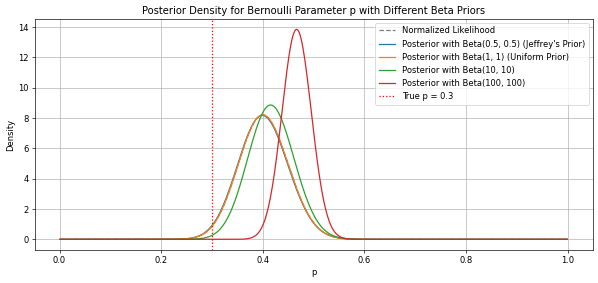

In [5]:
prior_params = [
    {'alpha': 0.5, 'beta': 0.5, 'label': 'Beta(0.5, 0.5) (Jeffrey\'s Prior)'},
    {'alpha': 1, 'beta': 1, 'label': 'Beta(1, 1) (Uniform Prior)'},
    {'alpha': 10, 'beta': 10, 'label': 'Beta(10, 10)'},
    {'alpha': 100, 'beta': 100, 'label': 'Beta(100, 100)'}
]

p_values = np.linspace(0.001, 0.999, 500) # Values for p to plot the density

plt.figure(figsize=(12, 5), dpi=60)

# Plot the likelihood (proportional to p^k * (1-p)^(n-k))
likelihood = beta.pdf(p_values, k + 1, n_bernoulli - k + 1) # Unnormalized likelihood, proportional to Beta(k+1, n-k+1)
# Normalize likelihood for plotting purposes, though it's not a density by itself
likelihood = likelihood / np.trapezoid(likelihood, p_values)
plt.plot(p_values, likelihood, linestyle='--', color='gray', label='Normalized Likelihood')

for prior in prior_params:
    alpha_post = prior['alpha'] + k
    beta_post = prior['beta'] + n_bernoulli - k
    posterior_density = beta.pdf(p_values, alpha_post, beta_post)
    plt.plot(p_values, posterior_density, label=f"Posterior with {prior['label']}")

plt.axvline(x=p_true, color='r', linestyle=':', label=f'True p = {p_true}')
plt.xlabel('p') ; plt.ylabel('Density')
plt.title('Posterior Density for Bernoulli Parameter p with Different Beta Priors') ; plt.legend() ; plt.grid(True) ; plt.show()

### Bayesian Inference for Poisson observations

Let $X_1, ..., X_n \sim \text{Poisson}(\lambda)$.

- Let $\lambda \sim \text{Gamma}(\alpha, \beta)$ be the prior. The posterior is also a Gamma. Compute the posterior mean (plot it).
- Compute the Jeffreys' prior and the posterior.

Given $X_i \sim \text{Poisson}(\lambda)$, the likelihood function for $n$ observations is $L(\lambda | X) = \prod_{i=1}^n \frac{e^{-\lambda} \lambda^{x_i}}{x_i!} = \frac{e^{-n\lambda} \lambda^{\sum x_i}}{\prod x_i!}$

Let's denote $S = \sum_{i=1}^n x_i$. The Gamma prior for $\lambda$ is $f(\lambda) = \frac{\beta^\alpha}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta\lambda}$.

The posterior density is proportional to the likelihood times the prior $f(\lambda | X) \propto L(\lambda | X) f(\lambda) \propto (e^{-n\lambda} \lambda^S) (\lambda^{\alpha-1} e^{-\beta\lambda})$, $f(\lambda | X) \propto \lambda^{S + \alpha - 1} e^{-(n + \beta)\lambda}$

This is the kernel of a Gamma distribution with parameters $\alpha_{post} = S + \alpha$, $\beta_{post} = n + \beta$. So, the posterior distribution is $\text{Gamma}(S + \alpha, n + \beta)$.

The mean of a Gamma distribution $\text{Gamma}(a, b)$ is $a/b$. Therefore, the posterior mean for $\lambda$ is
- $E[\lambda | X] = \frac{S + \alpha}{n + \beta}$

Number of observations (n): 100
True lambda: 5
Sum of observations (S): 522
Sample mean: 5.22
Prior: Gamma(2, 0.5)
Posterior: Gamma(524, 100.5)
Posterior mean of lambda: 5.21


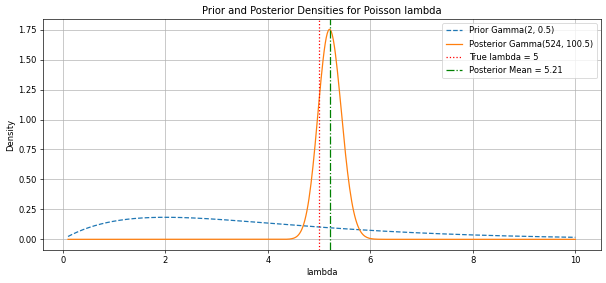

In [15]:
# Simulate a dataset from Poisson(lambda)
n_poisson = 100
lambda_true = 5
poisson_data = poisson.rvs(mu=lambda_true, size=n_poisson)

# Sum of observations
S = np.sum(poisson_data)

# Define Gamma prior parameters
alpha_prior = 2
beta_prior = 0.5

# Calculate posterior parameters
alpha_post = S + alpha_prior
beta_post = n_poisson + beta_prior

# Calculate posterior mean
posterior_mean_lambda = alpha_post / beta_post

# Plot the prior and posterior densities
lambda_values = np.linspace(0.1, 10, 500)

prior_density = gamma.pdf(lambda_values, a=alpha_prior, scale=1/beta_prior)
posterior_density = gamma.pdf(lambda_values, a=alpha_post, scale=1/beta_post)

#### Jeffreys' Prior for Poisson likelihood

Jeffreys' prior is proportional to the square root of the Fisher information. For a Poisson distribution $X \sim \text{Poisson}(\lambda)$, the probability mass function is $P(X=x|\lambda) = \frac{e^{-\lambda} \lambda^x}{x!}$.

The log-likelihood for a single observation is $\log L(\lambda|x) = -\lambda + x \log \lambda - \log(x!)$.

First derivative with respect to $\lambda$: $\frac{d}{d\lambda} \log L(\lambda|x) = -1 + \frac{x}{\lambda}$. Second derivative with respect to $\lambda$:
$\frac{d^2}{d\lambda^2} \log L(\lambda|x) = -\frac{x}{\lambda^2}$

The Fisher Information $I(\lambda)$ is the negative expectation of the second derivative:
$I(\lambda) = -E\left[ -\frac{X}{\lambda^2} \right] = E\left[ \frac{X}{\lambda^2} \right] = \frac{E[X]}{\lambda^2}$. Since $E[X] = \lambda$ for a Poisson distribution:
$I(\lambda) = \frac{\lambda}{\lambda^2} = \frac{1}{\lambda}$

Jeffreys' prior $f_J(\lambda)$ is proportional to $\sqrt{I(\lambda)}$
- $f_J(\lambda) \propto \sqrt{\frac{1}{\lambda}} = \lambda^{-1/2}$

This is an improper prior, which can be thought of as a $\text{Gamma}(1/2, 0)$ distribution (though usually expressed as $\text{Gamma}(\alpha=0.5, \beta=0)$ in this context where $\beta$ tends to 0).

#### Posterior with Jeffreys' Prior

Using the general form of the posterior for Poisson with Gamma prior, $\text{Gamma}(S + \alpha, n + \beta)$, and substituting the parameters for Jeffreys' prior ($\alpha = 1/2, \beta = 0$)
- $\alpha_{Jeffreys, post} = S + 1/2$, $\beta_{Jeffreys, post} = n + 0 = n$

So, the posterior with Jeffreys' prior is $\text{Gamma}(S + 1/2, n)$. The posterior mean for $\lambda$ with Jeffreys' prior is
- $E[\lambda | X]_{Jeffreys} = \frac{S + 1/2}{n}$

Jeffreys' Prior: f(lambda) proportional to lambda^(-0.5)
Posterior with Jeffreys' Prior: Gamma(522.5, 100)
Posterior mean of lambda (Jeffreys' Prior): 5.22


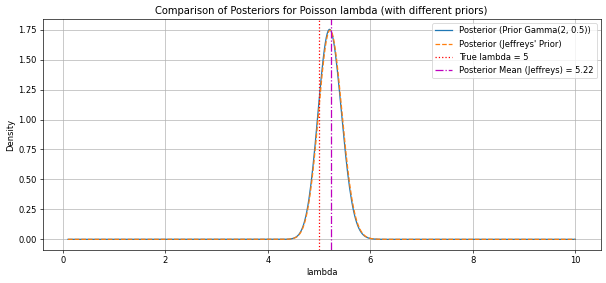

In [16]:
# Calculate posterior parameters with Jeffreys' prior
alpha_jeffreys_post = S + 0.5
beta_jeffreys_post = n_poisson

# Calculate posterior mean with Jeffreys' prior
posterior_mean_jeffreys = alpha_jeffreys_post / beta_jeffreys_post

# Plot the posterior density with Jeffreys' prior
posterior_jeffreys_density = gamma.pdf(lambda_values, a=alpha_jeffreys_post, scale=1/beta_jeffreys_post)